# CSQA Tuned Lens Analysis

This notebook trains a task-specific tuned lens for CommonsenseQA.

The tuned lens is a layer-specific affine translator that maps an intermediate hidden state into the model's final readout space. That is more faithful than a plain direct LM-head projection because intermediate layers are not naturally aligned with the final decoding basis.

The notebook is organized as:

1. data and model setup
2. hidden-state cache extraction
3. tuned-lens training
4. direct-vs-tuned evaluation
5. layerwise visualizations
6. saturation and agreement diagnostics


In [1]:
import copy
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

from src.data.load_csqa import load_csqa

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)


/home/ubuntu/Transformer-Decision-Traces/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

The defaults are intentionally moderate. Start with these to verify the method, then scale up if the results look stable.


In [2]:
MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"
TRAIN_SPLIT = "train"
EVAL_SPLIT = "validation"
TRAIN_LIMIT = 1024
EVAL_LIMIT = 512
MAX_SEQ_LEN = 256
EXTRACT_BATCH_SIZE = 4
TUNED_LENS_BATCH_SIZE = 64
TUNED_LENS_EPOCHS = 2
TUNED_LENS_LR = 1e-3
TUNED_LENS_WEIGHT_DECAY = 1e-5
SEED = 42
USE_BFLOAT16_IF_AVAILABLE = True
VOCAB_ENTROPY_SATURATION_THRESHOLD = 0.20
TRUE_ANSWER_MARGIN_OVER_VOCAB_THRESHOLD = 0.0


## Data And Model Setup

The model is loaded once. The tuned lens itself will be trained on cached hidden states, not by modifying the base model.


In [3]:
torch.manual_seed(SEED)
np.random.seed(SEED)

LETTERS = ["A", "B", "C", "D", "E"]

train_rows = load_csqa(split=TRAIN_SPLIT, limit=TRAIN_LIMIT).copy()
eval_rows = load_csqa(split=EVAL_SPLIT, limit=EVAL_LIMIT).copy()

for frame in [train_rows, eval_rows]:
    frame["n_choices"] = frame["csqa_choices"].map(len)
    frame["prompt_len_chars"] = frame["text"].str.len()
    assert frame["n_choices"].eq(5).all(), "Expected 5 choices for every CSQA row."

if torch.cuda.is_available():
    if USE_BFLOAT16_IF_AVAILABLE and torch.cuda.is_bf16_supported():
        model_dtype = torch.bfloat16
    else:
        model_dtype = torch.float16
    device_map = "auto"
else:
    model_dtype = torch.float32
    device_map = None

tok = AutoTokenizer.from_pretrained(MODEL_ID)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token
tok.padding_side = "left"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=model_dtype,
    device_map=device_map,
    attn_implementation="eager",
)
model.eval()

def build_answer_token_ids(tok):
    out = {}
    for letter in LETTERS:
        ids = tok(" " + letter, add_special_tokens=False)["input_ids"]
        if len(ids) != 1:
            raise ValueError(f"Answer token '{letter}' is not single-token: {ids}")
        out[letter] = int(ids[0])
    return out


answer_token_ids = build_answer_token_ids(tok)
answer_ids = [answer_token_ids[l] for l in LETTERS]
answer_id_tensor = torch.tensor(answer_ids, dtype=torch.long)

display(train_rows[["example_id", "answerKey", "prompt_len_chars"]].head())
print("train rows:", len(train_rows))
print("eval rows:", len(eval_rows))
print("answer token ids:", answer_token_ids)


`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 434/434 [00:36<00:00, 11.86it/s]


,example_id,answerKey,prompt_len_chars
0,42ed410d54eae473eb4578d8550259ed,A,200
1,a7059f15c9a41e642c05358ee3bfdad5,B,157
2,ae67f1af6b3e31ab97be57aa2519b565,A,166
3,bbc3ddd9f2ef318ee7dd8c728da8b5b9,D,154
4,b8ede90d3c3d058c817d5ce9beb2227f,C,170


train rows: 1024
eval rows: 512
answer token ids: {'A': 362, 'B': 425, 'C': 356, 'D': 422, 'E': 468}


## Helper Functions

These helpers:

- find the model's final normalization module
- encode prompts to the answer position
- detect whether the last hidden state needs final normalization before unembedding
- define a few descriptive diagnostics reused later


In [4]:
def get_final_norm_module(model):
    candidates = [
        "model.norm",
        "model.final_layernorm",
        "transformer.ln_f",
        "gpt_neox.final_layer_norm",
    ]
    for path in candidates:
        cur = model
        ok = True
        for part in path.split("."):
            if not hasattr(cur, part):
                ok = False
                break
            cur = getattr(cur, part)
        if ok:
            return cur
    return None


def encode_prompts(texts, tok, max_seq_len):
    batch = tok(
        list(texts),
        add_special_tokens=False,
        truncation=True,
        max_length=max_seq_len,
        padding=True,
        return_tensors="pt",
    )
    pos = []
    for mask in batch["attention_mask"]:
        nz = torch.nonzero(mask, as_tuple=False).view(-1)
        pos.append(int(nz[-1].item()))
    batch["decision_pos"] = torch.tensor(pos, dtype=torch.long)
    return batch


def first_true(mask):
    idx = np.flatnonzero(np.asarray(mask, dtype=bool))
    return float(idx[0]) if len(idx) else np.nan


def first_stable(mask):
    mask = np.asarray(mask, dtype=bool)
    for i in range(len(mask)):
        if mask[i] and mask[i:].all():
            return float(i)
    return np.nan


def first_numeric_stable(values):
    values = np.asarray(values)
    for i in range(len(values)):
        if np.all(values[i:] == values[i]):
            return float(i)
    return np.nan


def first_threshold_crossing(values, threshold, direction="le"):
    values = np.asarray(values, dtype=float)
    if direction == "le":
        idx = np.flatnonzero(values <= threshold)
    elif direction == "ge":
        idx = np.flatnonzero(values >= threshold)
    else:
        raise ValueError(direction)
    return float(idx[0]) if len(idx) else np.nan


def first_threshold_stable(values, threshold, direction="le"):
    values = np.asarray(values, dtype=float)
    for i in range(len(values)):
        tail = values[i:]
        if direction == "le" and np.all(tail <= threshold):
            return float(i)
        if direction == "ge" and np.all(tail >= threshold):
            return float(i)
    return np.nan


def rank_bucket(rank):
    rank = int(rank)
    if rank == 1:
        return "rank1_correct"
    if rank == 2:
        return "rank2_near_miss"
    return "rank3plus_hard"


final_norm = get_final_norm_module(model)
lm_head_weight = model.lm_head.weight.detach()
vocab_size = int(lm_head_weight.shape[0])
log_vocab_size = float(np.log(vocab_size))
log_answer_choice_count = float(np.log(len(LETTERS)))

probe_cpu = encode_prompts(eval_rows["text"].head(1), tok, MAX_SEQ_LEN)
probe_pos = int(probe_cpu["decision_pos"][0].item())
probe = {k: v.to(model.device) for k, v in probe_cpu.items() if k != "decision_pos"}
with torch.no_grad():
    probe_out = model(**probe, output_hidden_states=True, return_dict=True, use_cache=False)

hidden_probe = probe_out.hidden_states
L_plus_1 = len(hidden_probe)
L = L_plus_1 - 1
hidden_size = int(hidden_probe[-1].shape[-1])

choice_w = lm_head_weight[answer_id_tensor.to(lm_head_weight.device)].float()
target_logits = probe_out.logits[0, probe_pos, answer_id_tensor.to(probe_out.logits.device)].float().detach().cpu()
raw_last = hidden_probe[-1][0, probe_pos].float()
raw_logits = torch.mv(choice_w.cpu(), raw_last.detach().cpu())

if final_norm is not None:
    normed_last = final_norm(raw_last.unsqueeze(0)).squeeze(0)
    normed_logits = torch.mv(choice_w.cpu(), normed_last.detach().cpu())
    raw_err = torch.mean(torch.abs(raw_logits - target_logits)).item()
    normed_err = torch.mean(torch.abs(normed_logits - target_logits)).item()
    LAST_LAYER_NEEDS_NORM = bool(normed_err < raw_err)
else:
    LAST_LAYER_NEEDS_NORM = False


def maybe_apply_final_norm_gpu(h, layer_idx):
    if final_norm is None:
        return h
    if layer_idx < L:
        return final_norm(h)
    if LAST_LAYER_NEEDS_NORM:
        return final_norm(h)
    return h


final_norm_cpu = copy.deepcopy(final_norm).cpu().eval() if final_norm is not None else None


def maybe_apply_final_norm_cpu(h, layer_idx):
    if final_norm_cpu is None:
        return h
    if layer_idx < L:
        return final_norm_cpu(h)
    if LAST_LAYER_NEEDS_NORM:
        return final_norm_cpu(h)
    return h


print("L+1:", L_plus_1)
print("hidden_size:", hidden_size)
print("last layer needs final norm:", LAST_LAYER_NEEDS_NORM)


L+1: 37
hidden_size: 2048
last layer needs final norm: False


## Hidden-State Cache Extraction

We cache only the decision-position hidden states and the final readout target. This is enough for tuned-lens training and keeps the notebook much lighter than full trace extraction.


In [5]:
def extract_split_cache(frame, desc):
    hidden_blocks = []
    final_readout_blocks = []
    true_token_blocks = []

    for start in tqdm(range(0, len(frame), EXTRACT_BATCH_SIZE), total=int(math.ceil(len(frame) / EXTRACT_BATCH_SIZE)), desc=desc):
        batch_df = frame.iloc[start:start + EXTRACT_BATCH_SIZE].reset_index(drop=True)
        batch_cpu = encode_prompts(batch_df["text"], tok, MAX_SEQ_LEN)
        decision_pos = batch_cpu.pop("decision_pos")
        batch = {k: v.to(model.device) for k, v in batch_cpu.items()}
        decision_pos = decision_pos.to(model.device)

        with torch.no_grad():
            out = model(**batch, output_hidden_states=True, return_dict=True, use_cache=False)

        hidden_states = out.hidden_states
        per_layer_hidden = []
        for li in range(L_plus_1):
            h = hidden_states[li][torch.arange(hidden_states[li].shape[0], device=decision_pos.device), decision_pos].float()
            per_layer_hidden.append(h.detach().cpu())

        final_raw = hidden_states[-1][torch.arange(hidden_states[-1].shape[0], device=decision_pos.device), decision_pos].float()
        final_readout = maybe_apply_final_norm_gpu(final_raw, L).detach().cpu()
        true_ids = torch.tensor(
            [answer_token_ids[str(x)] for x in batch_df["answerKey"].tolist()],
            dtype=torch.long,
        )

        hidden_blocks.append(torch.stack(per_layer_hidden, dim=1))
        final_readout_blocks.append(final_readout)
        true_token_blocks.append(true_ids)

    return {
        "hidden": torch.cat(hidden_blocks, dim=0),
        "final_readout": torch.cat(final_readout_blocks, dim=0),
        "true_token_id": torch.cat(true_token_blocks, dim=0),
        "answerKey": frame["answerKey"].astype(str).tolist(),
        "example_id": frame["example_id"].tolist(),
    }


train_cache = extract_split_cache(train_rows, "extract train hidden cache")
eval_cache = extract_split_cache(eval_rows, "extract eval hidden cache")

print("train hidden cache:", tuple(train_cache["hidden"].shape))
print("eval hidden cache:", tuple(eval_cache["hidden"].shape))


extract eval hidden cache: 100%|██████████| 128/128 [00:06<00:00, 20.83it/s]

train hidden cache: (1024, 37, 2048)
eval hidden cache: (512, 37, 2048)


## Tuned Lens Training

Each intermediate layer gets its own affine translator. The translator is trained to match the model's final next-token distribution at the answer position.

The last layer is not trained. Its direct readout is already the model's own final readout.


In [6]:
class AffineTranslator(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.linear = nn.Linear(hidden_size, hidden_size)

    def forward(self, x):
        return self.linear(x)


train_device = model.device if torch.cuda.is_available() else torch.device("cpu")
lm_head_weight_train = lm_head_weight.to(train_device).float()

target_readout_train = train_cache["final_readout"].float()
teacher_logits_train = torch.matmul(target_readout_train.to(train_device), lm_head_weight_train.T)
teacher_probs_train = torch.softmax(teacher_logits_train, dim=-1).detach().cpu()

lenses = []
train_history_rows = []

for li in range(L_plus_1):
    if li == L:
        lenses.append(None)
        continue

    lens = AffineTranslator(hidden_size).to(train_device)
    optimizer = torch.optim.AdamW(lens.parameters(), lr=TUNED_LENS_LR, weight_decay=TUNED_LENS_WEIGHT_DECAY)

    ds = TensorDataset(train_cache["hidden"][:, li, :].float(), teacher_probs_train)
    dl = DataLoader(ds, batch_size=TUNED_LENS_BATCH_SIZE, shuffle=True)

    for epoch in range(1, TUNED_LENS_EPOCHS + 1):
        batch_losses = []
        lens.train()
        for xb, teacher_probs_b in dl:
            xb = xb.to(train_device)
            teacher_probs_b = teacher_probs_b.to(train_device)
            pred_readout = lens(xb)
            pred_logits = torch.matmul(pred_readout, lm_head_weight_train.T)
            pred_log_probs = torch.log_softmax(pred_logits, dim=-1)
            loss = F.kl_div(pred_log_probs, teacher_probs_b, reduction="batchmean")
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            batch_losses.append(float(loss.item()))

        train_history_rows.append(
            {
                "layer": li,
                "epoch": epoch,
                "mean_kl_loss": float(np.mean(batch_losses)),
            }
        )

    lens.eval()
    lenses.append(lens.cpu())

train_history_df = pd.DataFrame(train_history_rows)
display(train_history_df.head())


,layer,epoch,mean_kl_loss
0,0,1,4.612216
1,0,2,1.601619
2,1,1,2.896353
3,1,2,2.072076
4,2,1,3.150331


## Readout Evaluation

We evaluate two readout methods on the validation split:

- direct_logit_lens: direct projection from the intermediate hidden state
- tuned_lens: learned affine translator followed by the same LM head

This lets you see whether the tuned lens reveals cleaner internal decision structure than the naive direct readout.


In [7]:
def evaluate_method(cache, method_name):
    n = cache["hidden"].shape[0]
    true_token_ids = cache["true_token_id"].numpy()
    answer_key_letters = cache["answerKey"]

    full_vocab_entropy = np.zeros((n, L_plus_1), dtype=np.float32)
    vocab_entropy_norm = np.zeros((n, L_plus_1), dtype=np.float32)
    answer_choice_entropy = np.zeros((n, L_plus_1), dtype=np.float32)
    answer_choice_entropy_norm = np.zeros((n, L_plus_1), dtype=np.float32)
    entropy_norm_diff = np.zeros((n, L_plus_1), dtype=np.float32)
    true_answer_prob_vocab = np.zeros((n, L_plus_1), dtype=np.float32)
    true_answer_rank_vocab = np.zeros((n, L_plus_1), dtype=np.float32)
    true_answer_margin_vocab = np.zeros((n, L_plus_1), dtype=np.float32)
    true_answer_prob_choices = np.zeros((n, L_plus_1), dtype=np.float32)
    true_answer_rank_choices = np.zeros((n, L_plus_1), dtype=np.float32)
    answer_choice_gap = np.zeros((n, L_plus_1), dtype=np.float32)
    predicted_choice_index = np.zeros((n, L_plus_1), dtype=np.int64)
    predicted_vocab_token_id = np.zeros((n, L_plus_1), dtype=np.int64)

    for li in tqdm(range(L_plus_1), desc=f"evaluate {method_name}"):
        batch_logits = []
        for start in range(0, n, TUNED_LENS_BATCH_SIZE):
            xb = cache["hidden"][start:start + TUNED_LENS_BATCH_SIZE, li, :].float()

            if method_name == "direct_logit_lens":
                readout = maybe_apply_final_norm_cpu(xb, li)
            elif method_name == "tuned_lens":
                if li == L:
                    readout = maybe_apply_final_norm_cpu(xb, li)
                else:
                    readout = lenses[li](xb)
            else:
                raise ValueError(method_name)

            logits = torch.matmul(readout, lm_head_weight.float().cpu().T)
            batch_logits.append(logits.detach().cpu())

        full_vocab_logits = torch.cat(batch_logits, dim=0).numpy()
        full_vocab_logits = full_vocab_logits.astype(np.float32)
        full_vocab_log_probs = full_vocab_logits - np.logaddexp.reduce(full_vocab_logits, axis=1, keepdims=True)
        full_vocab_probs = np.exp(full_vocab_log_probs)
        full_vocab_entropy[:, li] = -(full_vocab_probs * full_vocab_log_probs).sum(axis=1)
        vocab_entropy_norm[:, li] = full_vocab_entropy[:, li] / log_vocab_size
        predicted_vocab_token_id[:, li] = np.argmax(full_vocab_logits, axis=1)

        true_logits = full_vocab_logits[np.arange(n), true_token_ids]
        true_answer_prob_vocab[:, li] = full_vocab_probs[np.arange(n), true_token_ids]
        true_answer_rank_vocab[:, li] = 1 + (full_vocab_logits > true_logits[:, None]).sum(axis=1)

        top2_idx = np.argpartition(full_vocab_logits, -2, axis=1)[:, -2:]
        top2_vals = np.take_along_axis(full_vocab_logits, top2_idx, axis=1)
        order = np.argsort(top2_vals, axis=1)[:, ::-1]
        top2_idx = np.take_along_axis(top2_idx, order, axis=1)
        top2_vals = np.take_along_axis(top2_vals, order, axis=1)
        best_other = np.where(top2_idx[:, 0] == true_token_ids, top2_vals[:, 1], top2_vals[:, 0])
        true_answer_margin_vocab[:, li] = true_logits - best_other

        choice_logits = full_vocab_logits[:, answer_ids]
        choice_log_probs = choice_logits - np.logaddexp.reduce(choice_logits, axis=1, keepdims=True)
        choice_probs = np.exp(choice_log_probs)
        answer_choice_entropy[:, li] = -(choice_probs * choice_log_probs).sum(axis=1)
        answer_choice_entropy_norm[:, li] = answer_choice_entropy[:, li] / log_answer_choice_count
        entropy_norm_diff[:, li] = vocab_entropy_norm[:, li] - answer_choice_entropy_norm[:, li]
        predicted_choice_index[:, li] = np.argmax(choice_logits, axis=1)
        sorted_choice = np.sort(choice_logits, axis=1)[:, ::-1]
        answer_choice_gap[:, li] = sorted_choice[:, 0] - sorted_choice[:, 1]

        true_choice_idx = np.array([LETTERS.index(k) for k in answer_key_letters], dtype=np.int64)
        true_answer_prob_choices[:, li] = choice_probs[np.arange(n), true_choice_idx]
        true_answer_rank_choices[:, li] = 1 + (choice_logits > choice_logits[np.arange(n), true_choice_idx][:, None]).sum(axis=1)

    rows = []
    for i in range(n):
        final_choice_idx = int(predicted_choice_index[i, -1])
        final_choice_letter = LETTERS[final_choice_idx]
        final_vocab_token = int(predicted_vocab_token_id[i, -1])
        full_vocab_agreement_curve = (predicted_vocab_token_id[i] == final_vocab_token)
        answer_choice_agreement_curve = (predicted_choice_index[i] == final_choice_idx)
        final_rank = int(true_answer_rank_choices[i, -1])

        rows.append(
            {
                "method": method_name,
                "example_id": cache["example_id"][i],
                "answerKey": answer_key_letters[i],
                "final_answer_choice_prediction": final_choice_letter,
                "final_answer_choice_is_correct": bool(final_choice_letter == answer_key_letters[i]),
                "answer_choice_rank_bucket": rank_bucket(final_rank),
                "final_vocab_entropy_normalized": float(vocab_entropy_norm[i, -1]),
                "final_answer_choice_entropy_normalized": float(answer_choice_entropy_norm[i, -1]),
                "final_entropy_normalized_difference": float(entropy_norm_diff[i, -1]),
                "final_true_answer_probability_over_vocab": float(true_answer_prob_vocab[i, -1]),
                "final_true_answer_rank_over_vocab": float(true_answer_rank_vocab[i, -1]),
                "final_true_answer_margin_over_vocab": float(true_answer_margin_vocab[i, -1]),
                "final_true_answer_probability_within_choices": float(true_answer_prob_choices[i, -1]),
                "final_true_answer_rank_within_choices": float(true_answer_rank_choices[i, -1]),
                "final_answer_choice_top1_top2_logit_gap": float(answer_choice_gap[i, -1]),
                "first_low_vocab_entropy_layer": first_threshold_crossing(vocab_entropy_norm[i], VOCAB_ENTROPY_SATURATION_THRESHOLD, direction="le"),
                "true_answer_rank_stable_layer": first_numeric_stable(true_answer_rank_vocab[i]),
                "true_answer_margin_over_vocab_stable_layer": first_threshold_stable(true_answer_margin_vocab[i], TRUE_ANSWER_MARGIN_OVER_VOCAB_THRESHOLD, direction="ge"),
                "first_full_vocab_agreement_with_final_layer": first_true(full_vocab_agreement_curve),
                "stable_full_vocab_agreement_with_final_layer": first_stable(full_vocab_agreement_curve),
                "first_answer_choice_agreement_with_final_layer": first_true(answer_choice_agreement_curve),
                "stable_answer_choice_agreement_with_final_layer": first_stable(answer_choice_agreement_curve),
                "vocab_entropy_normalized_curve": vocab_entropy_norm[i].copy(),
                "answer_choice_entropy_normalized_curve": answer_choice_entropy_norm[i].copy(),
                "entropy_normalized_difference_curve": entropy_norm_diff[i].copy(),
                "true_answer_margin_over_vocab_curve": true_answer_margin_vocab[i].copy(),
                "true_answer_rank_over_vocab_curve": true_answer_rank_vocab[i].copy(),
                "answer_choice_top1_top2_logit_gap_curve": answer_choice_gap[i].copy(),
                "true_answer_rank_within_choices_curve": true_answer_rank_choices[i].copy(),
                "full_vocab_prediction_agreement_with_final_curve": full_vocab_agreement_curve.astype(np.float32),
                "answer_choice_prediction_agreement_with_final_curve": answer_choice_agreement_curve.astype(np.float32),
            }
        )

    return pd.DataFrame(rows)


direct_df = evaluate_method(eval_cache, "direct_logit_lens")
tuned_df = evaluate_method(eval_cache, "tuned_lens")

display(
    pd.concat(
        [
            direct_df.groupby("method")[["final_answer_choice_is_correct", "final_true_answer_margin_over_vocab"]].mean(),
            tuned_df.groupby("method")[["final_answer_choice_is_correct", "final_true_answer_margin_over_vocab"]].mean(),
        ]
    )
)


evaluate tuned_lens: 100%|██████████| 37/37 [07:00<00:00, 11.37s/it]


,final_answer_choice_is_correct,final_true_answer_margin_over_vocab
method,,
direct_logit_lens,0.791016,5.189056
tuned_lens,0.791016,5.189056


## Training Loss By Layer

This plot shows whether the layer translators are actually learning. Lower KL means the tuned lens is matching the model's final prediction distribution more closely.


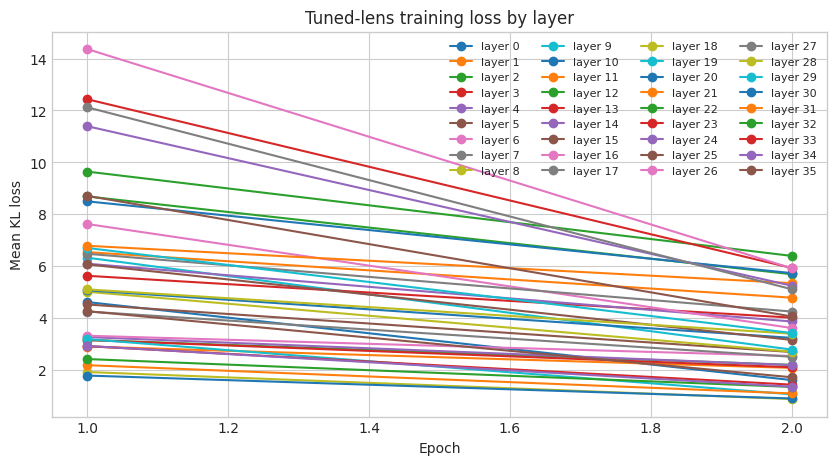

In [8]:
plt.figure(figsize=(10, 5))
for li, g in train_history_df.groupby("layer"):
    plt.plot(g["epoch"], g["mean_kl_loss"], marker="o", label=f"layer {li}")
plt.xlabel("Epoch")
plt.ylabel("Mean KL loss")
plt.title("Tuned-lens training loss by layer")
plt.legend(ncol=4, fontsize=8)
plt.show()


## Direct Vs Tuned Layerwise Curves

These plots compare the naive direct readout against the tuned lens. If the tuned lens is useful, the tuned curves should be cleaner and more aligned with the final decision structure.


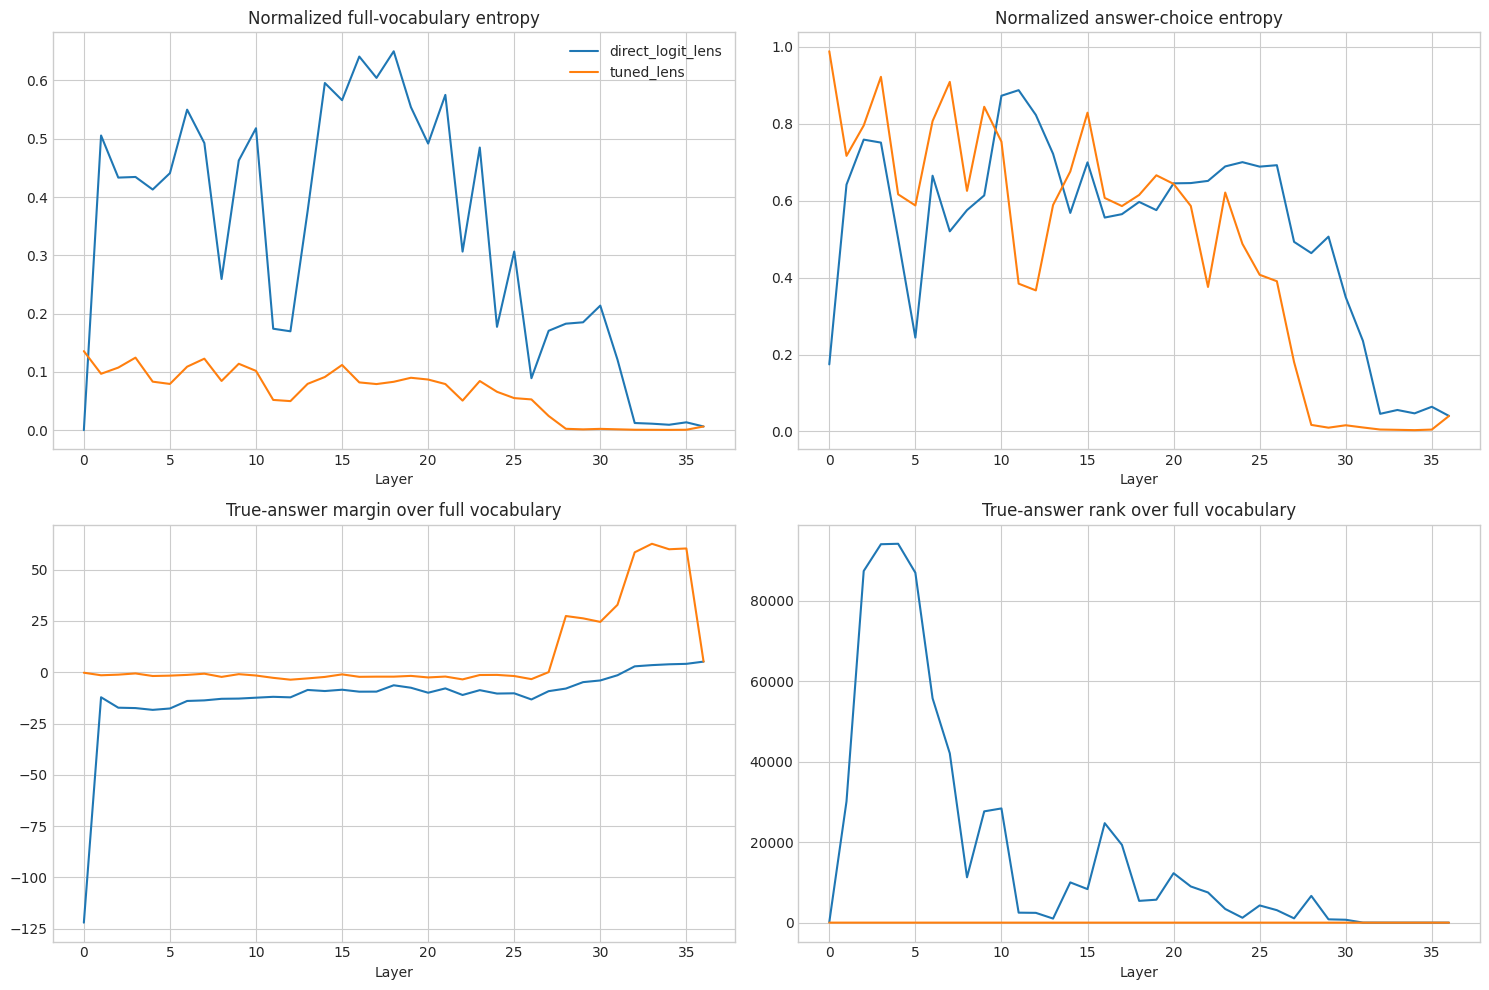

In [9]:
layers = np.arange(L_plus_1)


def stack_curve(frame, col):
    return np.stack(frame[col].to_list(), axis=0)


curve_compare_specs = [
    ("vocab_entropy_normalized_curve", "Normalized full-vocabulary entropy"),
    ("answer_choice_entropy_normalized_curve", "Normalized answer-choice entropy"),
    ("true_answer_margin_over_vocab_curve", "True-answer margin over full vocabulary"),
    ("true_answer_rank_over_vocab_curve", "True-answer rank over full vocabulary"),
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for ax, (col, title) in zip(axes, curve_compare_specs):
    ax.plot(layers, stack_curve(direct_df, col).mean(axis=0), label="direct_logit_lens")
    ax.plot(layers, stack_curve(tuned_df, col).mean(axis=0), label="tuned_lens")
    ax.set_title(title)
    ax.set_xlabel("Layer")

axes[0].legend()
plt.tight_layout()
plt.show()


## Tuned-Lens Curves By Outcome Bucket

This section focuses only on the tuned-lens readout. The question is whether correct, near-miss, and hard-miss examples follow visibly different internal trajectories.


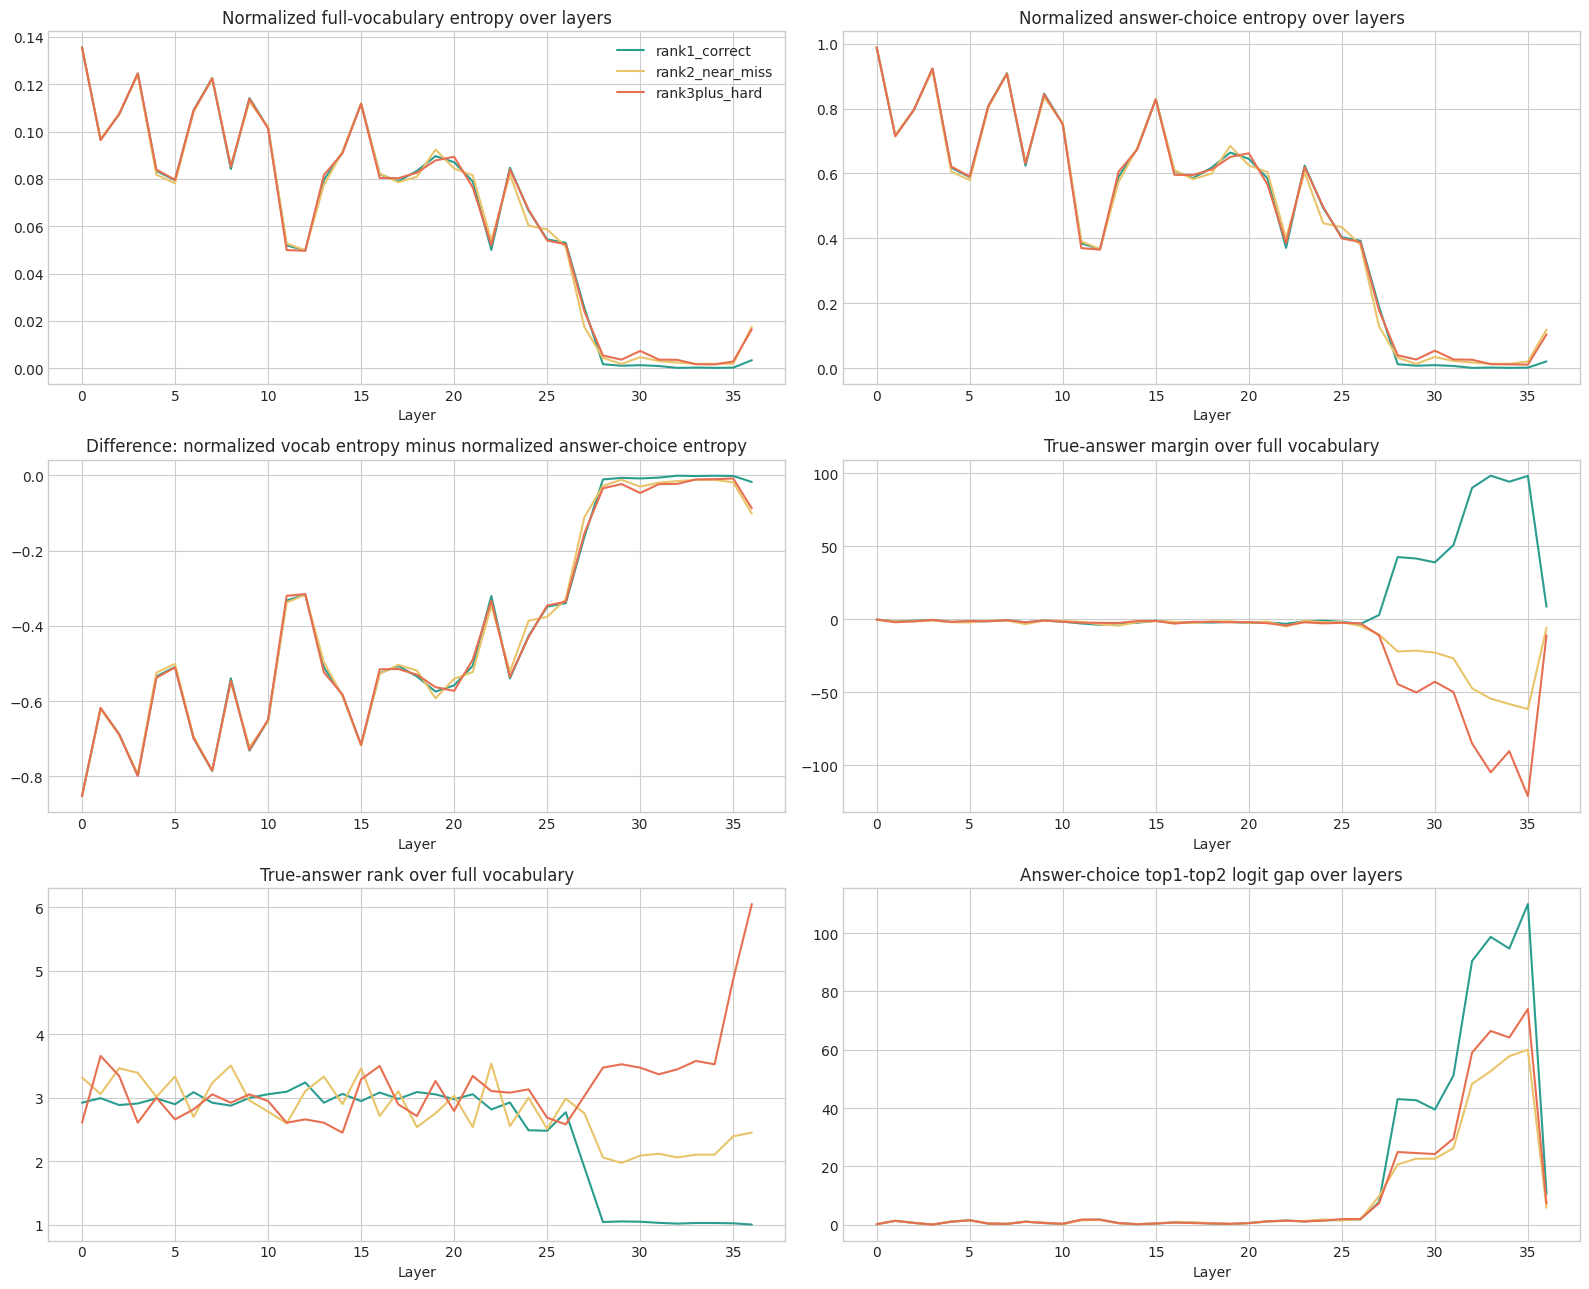

In [10]:
bucket_order = ["rank1_correct", "rank2_near_miss", "rank3plus_hard"]
bucket_colors = {
    "rank1_correct": "#2a9d8f",
    "rank2_near_miss": "#e9c46a",
    "rank3plus_hard": "#e76f51",
}


def mean_curve(frame, col, bucket):
    mat = stack_curve(frame, col)
    mask = frame["answer_choice_rank_bucket"].eq(bucket).to_numpy()
    return mat[mask].mean(axis=0)


curve_specs = [
    ("vocab_entropy_normalized_curve", "Normalized full-vocabulary entropy over layers"),
    ("answer_choice_entropy_normalized_curve", "Normalized answer-choice entropy over layers"),
    ("entropy_normalized_difference_curve", "Difference: normalized vocab entropy minus normalized answer-choice entropy"),
    ("true_answer_margin_over_vocab_curve", "True-answer margin over full vocabulary"),
    ("true_answer_rank_over_vocab_curve", "True-answer rank over full vocabulary"),
    ("answer_choice_top1_top2_logit_gap_curve", "Answer-choice top1-top2 logit gap over layers"),
]

fig, axes = plt.subplots(3, 2, figsize=(16, 13))
axes = axes.ravel()

for ax, (col, title) in zip(axes, curve_specs):
    for bucket in bucket_order:
        ax.plot(layers, mean_curve(tuned_df, col, bucket), label=bucket, color=bucket_colors[bucket])
    ax.set_title(title)
    ax.set_xlabel("Layer")

axes[0].legend()
plt.tight_layout()
plt.show()


## Hit@k Over Layers

This plot shows how often the true answer is already inside the top-k answer choices over depth. It is a compact way to see whether the tuned lens surfaces the correct answer earlier than the direct readout.


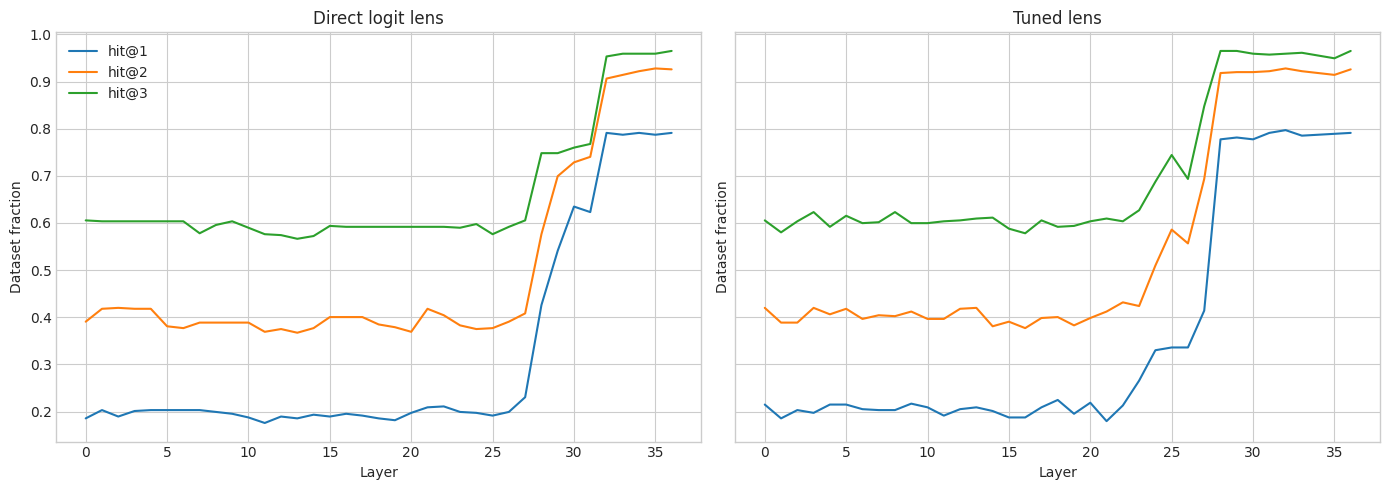

In [11]:
def hit_curves(frame):
    rank_curve = stack_curve(frame, "true_answer_rank_within_choices_curve")
    return {
        "hit@1": (rank_curve <= 1).mean(axis=0),
        "hit@2": (rank_curve <= 2).mean(axis=0),
        "hit@3": (rank_curve <= 3).mean(axis=0),
    }


direct_hits = hit_curves(direct_df)
tuned_hits = hit_curves(tuned_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, title, hits in [
    (axes[0], "Direct logit lens", direct_hits),
    (axes[1], "Tuned lens", tuned_hits),
]:
    for label, vals in hits.items():
        ax.plot(layers, vals, label=label)
    ax.set_title(title)
    ax.set_xlabel("Layer")
    ax.set_ylabel("Dataset fraction")

axes[0].legend()
plt.tight_layout()
plt.show()


## Saturation Diagnostics

These are descriptive indicators of how early the trace appears to settle:

- first_low_vocab_entropy_layer
- true_answer_rank_stable_layer
- true_answer_margin_over_vocab_stable_layer

They are useful for understanding failure modes, even though some of them use the true answer and therefore are not deployment-time features.


first_low_vocab_entropy_layer             true_answer_rank_stable_layer                true_answer_margin_over_vocab_stable_layer               
                                                   mean median  std                          mean median     std                                       mean median     std
answer_choice_rank_bucket                                                                                                                                                 
rank1_correct                                       0.0    0.0  0.0                       27.5358   28.0  2.0054                                    27.5358   28.0  2.0054
rank2_near_miss                                     0.0    0.0  0.0                       32.9275   35.0  3.7350                                        NaN    NaN     NaN
rank3plus_hard                                      0.0    0.0  0.0                       35.8158   36.0  0.3929                                        NaN    NaN     NaN

/home/ubuntu/Transformer-Decision-Traces/.venv/lib/python3.11/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


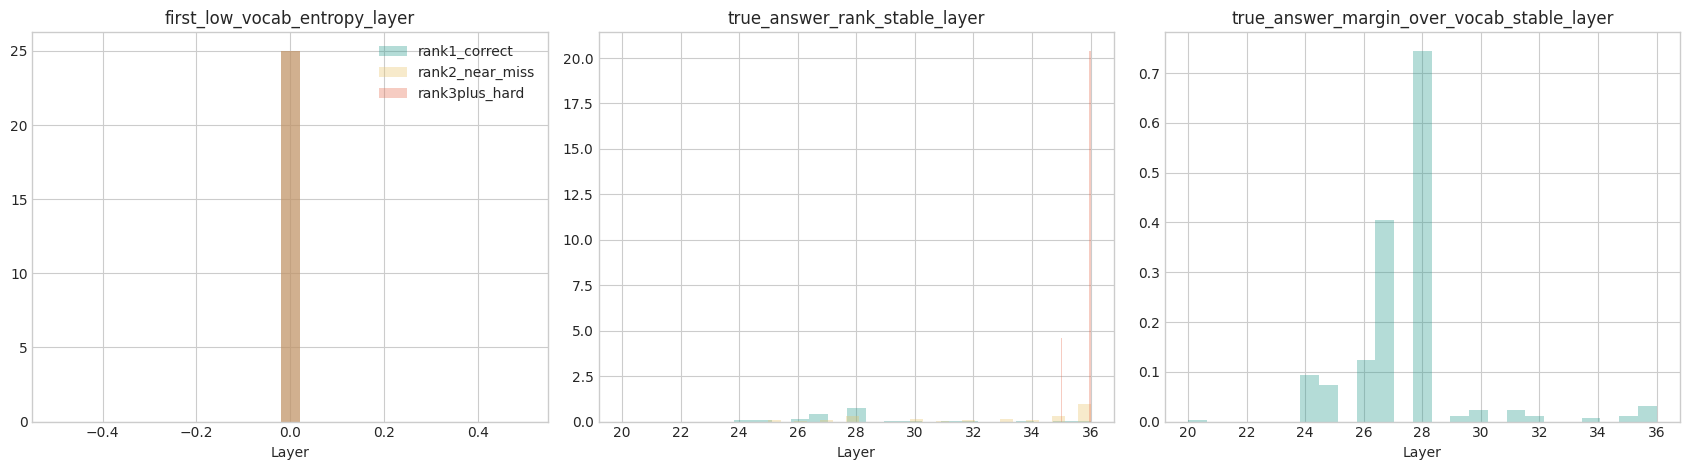

In [12]:
saturation_cols = [
    "first_low_vocab_entropy_layer",
    "true_answer_rank_stable_layer",
    "true_answer_margin_over_vocab_stable_layer",
]

display(
    tuned_df.groupby("answer_choice_rank_bucket")[saturation_cols]
    .agg(["mean", "median", "std"])
    .round(4)
)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

for ax, col in zip(axes, saturation_cols):
    for bucket in bucket_order:
        vals = pd.to_numeric(
            tuned_df.loc[tuned_df["answer_choice_rank_bucket"].eq(bucket), col],
            errors="coerce",
        ).dropna()
        ax.hist(vals, bins=25, density=True, alpha=0.35, color=bucket_colors[bucket], label=bucket)
    ax.set_title(col)
    ax.set_xlabel("Layer")

axes[0].legend()
plt.tight_layout()
plt.show()


## Agreement With The Final Prediction

These diagnostics do not use ground truth. They show when a layer already agrees with the model's own final prediction.

- full_vocab_prediction_agreement_with_final_curve
- answer_choice_prediction_agreement_with_final_curve


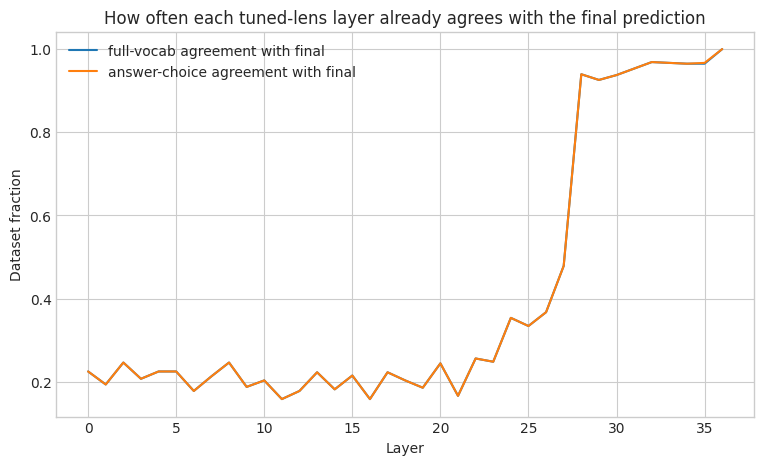

first_full_vocab_agreement_with_final_layer                stable_full_vocab_agreement_with_final_layer                 \
                                                                 mean median     std                                         mean median     std   
answer_choice_rank_bucket                                                                                                                          
rank1_correct                                                  3.3037    2.0  3.7409                                      27.5358   28.0  2.0054   
rank2_near_miss                                                2.8551    2.0  3.3267                                      28.8551   28.0  3.5780   
rank3plus_hard                                                 2.5526    1.5  3.3828                                      28.7105   28.0  3.0127   

                          first_answer_choice_agreement_with_final_layer                stable_answer_choice_agreement_with_final_layer                 
                                                                    mean median     std                                            mean median     std  
answer_choice_rank_bucket                                                                                                                               
rank1_correct                                                     3.3037    2.0  3.7409                                         27.5358   28.0  2.0054  
rank2_near_miss                                                   2.8551    2.0  3.3267                                         28.8406   28.0  3.5506  
rank3plus_hard                                                    2.5526    1.5  3.3828                                         28.7105   28.0  3.0127

In [13]:
full_vocab_agreement_curve = stack_curve(tuned_df, "full_vocab_prediction_agreement_with_final_curve")
answer_choice_agreement_curve = stack_curve(tuned_df, "answer_choice_prediction_agreement_with_final_curve")

plt.figure(figsize=(9, 5))
plt.plot(layers, full_vocab_agreement_curve.mean(axis=0), label="full-vocab agreement with final")
plt.plot(layers, answer_choice_agreement_curve.mean(axis=0), label="answer-choice agreement with final")
plt.xlabel("Layer")
plt.ylabel("Dataset fraction")
plt.title("How often each tuned-lens layer already agrees with the final prediction")
plt.legend()
plt.show()

agreement_summary_cols = [
    "first_full_vocab_agreement_with_final_layer",
    "stable_full_vocab_agreement_with_final_layer",
    "first_answer_choice_agreement_with_final_layer",
    "stable_answer_choice_agreement_with_final_layer",
]

display(
    tuned_df.groupby("answer_choice_rank_bucket")[agreement_summary_cols]
    .agg(["mean", "median", "std"])
    .round(4)
)


## Final Summary

If the tuned lens is helping, you should expect:

- lower or cleaner layerwise entropy than the direct lens
- earlier growth in true-answer margin
- earlier appearance of the true answer inside top-k answer choices
- more interpretable separation between correct, near-miss, and hard-miss examples

The tuned lens does not change the base model. It only gives a better measurement of what the intermediate layers already encode.
